# Test column detector on a real floor plan

Tiles a large floor-plan image, runs `column_detect.pt` per tile, merges detections across tile overlaps with NMS, and saves an annotated PNG.

Tile geometry matches `generate_column.py` training config (`TILE_SIZE=1280`, `TILE_STEP=1080`).

In [1]:
from pathlib import Path
import numpy as np
import torch
import torchvision.ops as tvops
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO
import matplotlib.pyplot as plt

Image.MAX_IMAGE_PIXELS = None  # large floor plans exceed Pillow's default cap

In [2]:
# ── CONFIG ──────────────────────────────────────────────────────────────
# WEIGHTS    = Path('column_detect.pt')
# WEIGHTS = Path('/home/jiezhi/Documents/1-column-train/runs/detect/column_detector/weights/last.pt')
WEIGHTS = Path('retrained_column_detection.pt')
IMAGE_PATH = Path('/home/jiezhi/Documents/TGCH floor plan/L3.jpg')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

TILE_SIZE  = 1280
TILE_STEP  = 1080            # 200 px overlap, same as training
CONF_TH    = 0.25            # detection confidence threshold
IOU_TH     = 0.45            # NMS IoU threshold (across tiles)
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'

print(f'weights : {WEIGHTS}')
print(f'image   : {IMAGE_PATH}')
print(f'device  : {DEVICE}')

weights : retrained_column_detection.pt
image   : /home/jiezhi/Documents/TGCH floor plan/L3.jpg
device  : 0


In [3]:
# ── LOAD MODEL + IMAGE ───────────────────────────────────────────────────
# Walk up to find scripts/ so the notebook works regardless of cwd.
import sys
from pathlib import Path as _Path
_search = [_Path.cwd(), *_Path.cwd().parents]
ROOT = next(
    (p for p in _search if (p / 'scripts' / 'tiled_inference.py').exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        f'Could not locate scripts/tiled_inference.py walking up from {_Path.cwd()}'
    )
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

model = YOLO(str(WEIGHTS))
img   = Image.open(IMAGE_PATH).convert('RGB')
W, H  = img.size
print(f'image size: {W} × {H} px')


image size: 13480 × 9536 px


In [4]:
# ── TILED INFERENCE via shared helper ────────────────────────────────────
# Use scripts/tiled_inference.tiled_predict so this notebook and
# correct_detections.ipynb cannot drift on tile geometry, white-padding, or
# per-tile detection-count tracking.
from tiled_inference import tiled_predict, n_tiles_for_image

INPUT_DPI = 300   # second public knob — must match the rasterisation DPI

all_boxes, all_scores, tile_counts = tiled_predict(
    model, img,
    tile=TILE_SIZE, step=TILE_STEP,
    conf=CONF_TH, iou=IOU_TH,
    device=DEVICE,
)
n_grid = n_tiles_for_image(W, H, tile=TILE_SIZE, step=TILE_STEP)
print(f'tiles processed: {len(tile_counts)}  (grid: {n_grid})')
print(f'raw detections (pre-NMS): {len(all_boxes)}')
if tile_counts:
    print(f'per-tile dets: min={min(tile_counts)} max={max(tile_counts)} '
          f'mean={sum(tile_counts)/len(tile_counts):.2f}')


tiles processed: 117  (grid: 117)
raw detections (pre-NMS): 614
per-tile dets: min=0 max=33 mean=5.25


In [5]:
# ── POST-PROCESSING via shared module ───────────────────────────────────
# Imports `run_pipeline` from scripts/postprocess_pipeline.py so this
# notebook and correct_detections.ipynb stay in lockstep. All filter
# constants live in PostprocessConfig; override there, not here.
from postprocess_pipeline import run_pipeline, DEFAULT_CONFIG, format_audit
from ood_detector import OutOfDistributionError

img_gray = np.asarray(img.convert('L'))

# `tile_counts` is REQUIRED — cell 4 must have been run. If you see
# NameError below, run cell 4 first; OOD spread check depends on it.
try:
    boxes_final, scores_final, audit = run_pipeline(
        img_gray, all_boxes, all_scores,
        config=DEFAULT_CONFIG,
        input_dpi=INPUT_DPI,
        tile_detection_counts=tile_counts,
    )
except OutOfDistributionError as e:
    print(f'OOD HARD FAILURE: {e}')
    print('Refusing to emit predictions. Fix the rasterisation and re-run.')
    boxes_final  = np.zeros((0, 4), dtype=np.float32)
    scores_final = np.zeros((0,),    dtype=np.float32)
    raise

print(format_audit(audit))
print()
print(f'FINAL columns detected                : {len(boxes_final)}')


raw                   : 614
after aspect          : 594
after size            : 591
after shape           : 544
after OCR text        : 293
after centre-NMS      : 192
FINAL                 : 192

FINAL columns detected                : 192


In [6]:
# ── ANNOTATED OUTPUT ─────────────────────────────────────────────────────
annotated = img.copy()
draw = ImageDraw.Draw(annotated)
lw = max(2, min(W, H) // 1500)
for (x1, y1, x2, y2), s in zip(boxes_final, scores_final):
    draw.rectangle([x1, y1, x2, y2], outline=(220, 30, 30), width=lw)

out_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_columns.png'
annotated.save(out_path, optimize=True)
print(f'saved → {out_path.resolve()}')
print(f'total columns: {len(boxes_final)}')

saved → /home/jiezhi/Documents/1-column-train/output/L3_columns.png
total columns: 192


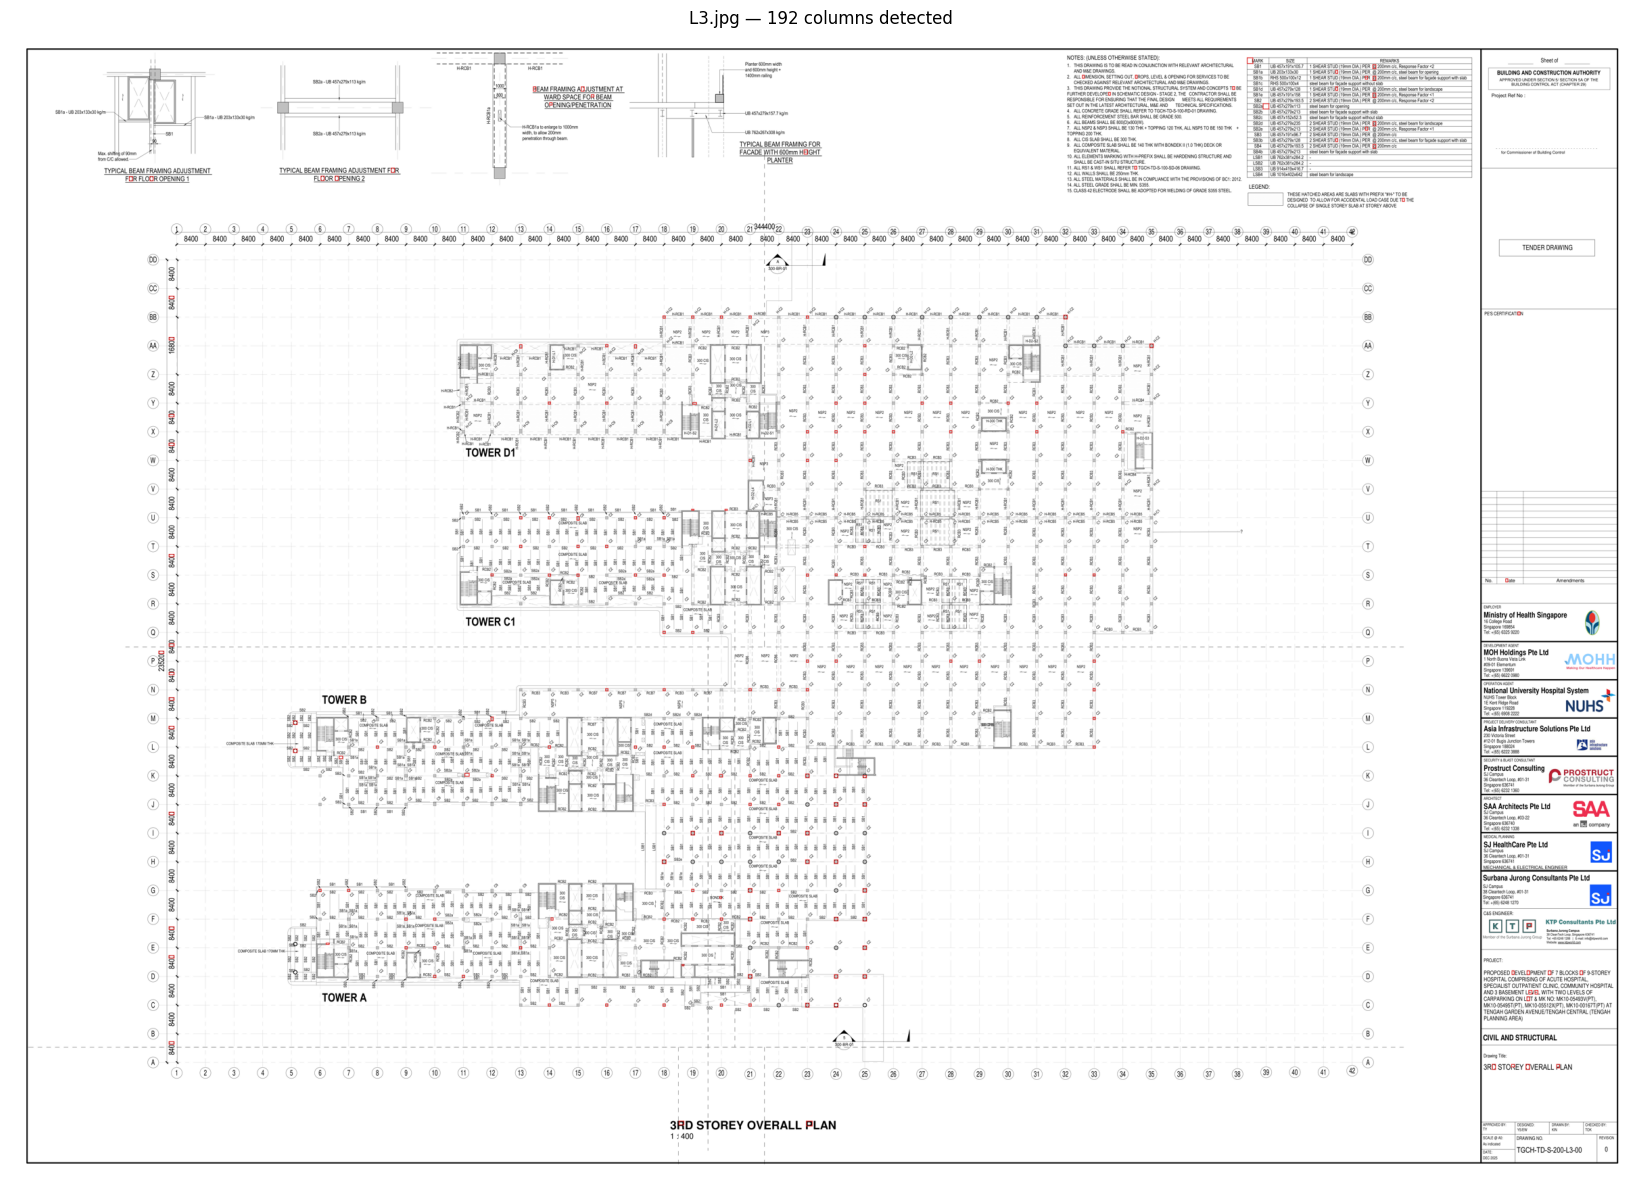

In [7]:
# ── PREVIEW (downscaled) ─────────────────────────────────────────────────
preview = annotated.copy()
preview.thumbnail((2400, 2400))
fig, ax = plt.subplots(figsize=(18, 12))
ax.imshow(preview)
ax.set_title(f'{IMAGE_PATH.name} — {len(boxes_final)} columns detected')
ax.axis('off')
plt.tight_layout()
plt.show()

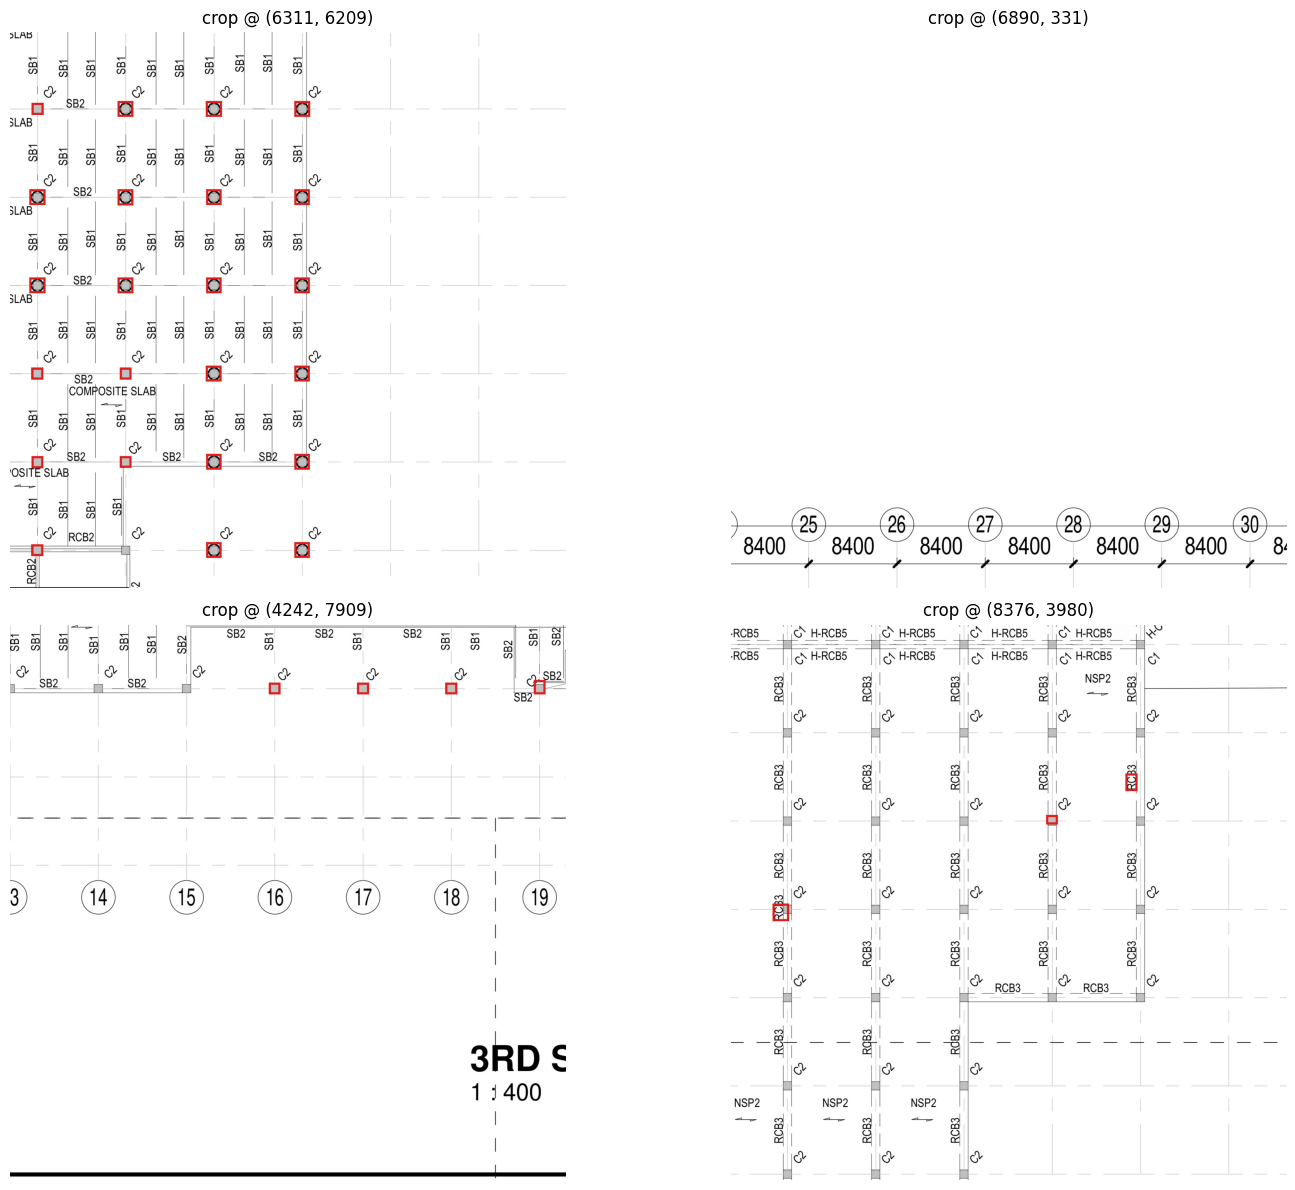

In [8]:
# ── ZOOM CROPS for visual QA ─────────────────────────────────────────────
# Pull 4 random 1500-px crops so you can eyeball detection quality at full res.
import random
random.seed(0)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
crop_size = 1500
for ax in axes.flatten():
    cx = random.randint(0, max(0, W - crop_size))
    cy = random.randint(0, max(0, H - crop_size))
    ax.imshow(annotated.crop((cx, cy, cx + crop_size, cy + crop_size)))
    ax.set_title(f'crop @ ({cx}, {cy})')
    ax.axis('off')
plt.tight_layout()
plt.show()

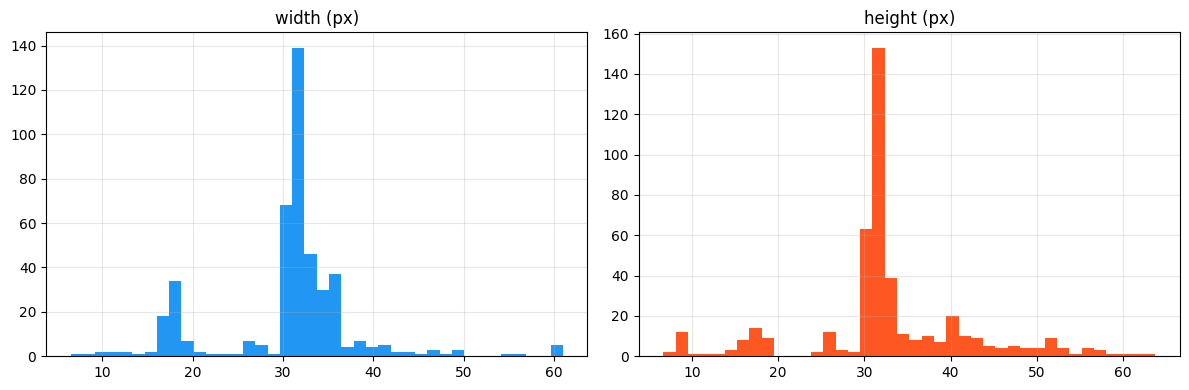

width  median 31.5 px (min 6, max 61)
height median 31.7 px (min 7, max 64)


In [10]:
# ── DETECTION SIZE HISTOGRAM ─────────────────────────────────────────────
# Lets you see whether round columns (24-42 px in tile space ≈ 24-42 px here)
# are picked up at the expected scale, separate from C2 squares (20-34 px).
widths  = boxes_final[:, 2] - boxes_final[:, 0]
heights = boxes_final[:, 3] - boxes_final[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=40, color='#2196F3'); axes[0].set_title('width (px)')
axes[1].hist(heights, bins=40, color='#FF5722'); axes[1].set_title('height (px)')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'width  median {np.median(widths):.1f} px (min {widths.min():.0f}, max {widths.max():.0f})')
print(f'height median {np.median(heights):.1f} px (min {heights.min():.0f}, max {heights.max():.0f})')